In [ ]:
import pandas as pd
import glob
import re
import os
import seaborn as sns
import numpy as np
import scanpy as sc
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, ttest_ind

def extract_feature(adata, feature):

    ad_subset = adata[:, adata.var['feature_types']==feature]

    obs_names = adata.obs.index.tolist()
    var_names = ad_subset.var_names
    array = ad_subset.X.toarray()

    df = pd.DataFrame(
        array,
        index=obs_names,
        columns=var_names
    )

    return df

tumours = [
 'AT3',
 'AT4',
 'AT5',
 'AT6',
 'AT7',
 'AT9',
 'AT10',
 'AT11',
 'AT12',
 'AT13',
 'AT14',
 'AT15',
]

output_dir = '../../../data/EDFig3/'

In [ ]:
# Load cell2loc output
sp_directory = '../../../data/GBM_LEAP_annotations/web_atlas/anndata/'
files = glob.glob(sp_directory+'*h5ad')

# load cell state spatial data
abundance_output = {}
niche_output = {}
histopath_output = {}

for tumour in tumours:
    tumour_files = [i for i in files if tumour+'-' in i]

    abundances = []
    niches = []
    histopaths = []
    
    for filepath in tumour_files:
        ad_tmp = sc.read_h5ad(filepath)
    
        abundances.append(extract_feature(ad_tmp, 'Cell state abundances'))
        niches.append(extract_feature(ad_tmp, 'Spatial niche abundances'))

        if 'Histopath annotation overlap' in set(ad_tmp.var['feature_types']):
            histopaths.append(extract_feature(ad_tmp, 'Histopath annotation overlap'))

    abundance_output[tumour] = pd.concat(abundances)
    niche_output[tumour] = pd.concat(niches)
    if len(histopaths)>0:
        histopath_output[tumour] = pd.concat(histopaths)

    del(ad_tmp)

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/annd

In [ ]:
# Load NMF output

cell2loc_nmf_output = {}
for tumour in tumours:
    cell2loc_nmf_dir = '../data/niche_validation/cell2loc_nmf/'
    file = '{}_niche_loadings.csv'.format(tumour)
    
    df = pd.read_csv(os.path.join(cell2loc_nmf_dir, file), index_col=0)
    cell2loc_nmf_output[tumour] = df

# get TM list
TM_list = []
for k in cell2loc_nmf_output:
    TM_list.append(list(cell2loc_nmf_output[k].columns))
TM_list = [i for l in TM_list for i in l]
TM_list = sorted(list(set(TM_list)))

# Top cell state

- Get top cell states
- Calculate the correlation of top cell state with other TMs

In [ ]:
mean_TM_abundances = []
top_cts = []
for TM in TM_list:

    # get TM abundances for each tumour
    TM_abundances = []
    for tumour in tumours:
        if TM in cell2loc_nmf_output[tumour].columns:
            TM_abundances.append(cell2loc_nmf_output[tumour][[TM]])
    TM_abundances = pd.concat(TM_abundances).reset_index().groupby('index', 
                                                                   as_index=False).mean()
    TM_abundances = TM_abundances.rename(columns={TM:'abundance'})
    TM_abundances['TM'] = TM
    TM_abundances = TM_abundances.set_index(['index', 'TM'])

    top_cts.append(TM_abundances.sort_values('abundance').tail(1))
    mean_TM_abundances.append(TM_abundances)
mean_TM_abundances = pd.concat(mean_TM_abundances)
top_cts = pd.concat(top_cts)

In [ ]:
# get top abundances:
top_ct_list = top_cts.reset_index()['index'].tolist()

In [ ]:
# feed top abundances into correlation:
median_TM_ct_corrs = []
for ct in top_ct_list:
    for tumour in tumours:
        for TM in TM_list:

            # relabel TMs for paper
            if 'Hypoxic' in TM:
                TM = TM+' (niche)'
            if TM=='Neuron-like':
                TM = 'Dev-like (Neuron)'

            if TM in niche_output[tumour].columns:
                if ct in abundance_output[tumour].columns:
                    r,p = pearsonr(abundance_output[tumour][ct],
                                     niche_output[tumour][TM])
                    df = pd.DataFrame({'index':ct, 'TM':TM, 'r':r, 'p':p}, index=[0])
                    median_TM_ct_corrs.append(df)
median_TM_ct_corrs = pd.concat(median_TM_ct_corrs)
median_TM_ct_corrs = median_TM_ct_corrs.groupby(['index', 'TM']).median()

In [ ]:
# prep df to ensure symmetry:
mean_TM_abundances = mean_TM_abundances[mean_TM_abundances.index.get_level_values("index").isin(top_ct_list)]

tms_A = set(mean_TM_abundances.index.get_level_values('TM'))
tms_B = set(median_TM_ct_corrs.index.get_level_values('TM'))
print(len(tms_A)==len(tms_B))
print([i for i in tms_A if i not in tms_B])

t_A = set(mean_TM_abundances.index.get_level_values('index'))
t_B = set(median_TM_ct_corrs.index.get_level_values('index'))
print(len(t_A)==len(t_B))
print([i for i in t_A if i not in t_B])

True
[]
True
[]


In [ ]:
mean_TM_abundances = mean_TM_abundances.rename(
    index={
        "Hypoxic 1": "Hypoxic 1 (niche)",
        "Hypoxic 2": "Hypoxic 2 (niche)",
        "Neuron-like": "Dev-like (Neuron)",
    },
    level="TM"
)

In [ ]:
plot_df = pd.concat([mean_TM_abundances, median_TM_ct_corrs], axis=1).reset_index()

In [ ]:
TM_order_from_paper = [
    "Hypoxic 1 (niche)",
    "Gliosis",
    "Gliosis transition",
    "Hypoxic 2 (niche)",
    "Proliferative",
    "Dev-like (Neuron)",
    "Dev-like (AC)",
    "Gliosis (diffuse)",
    "Dev-like (OPC)",
    "Vasculature",
    "Immune (TAMs)",
    "Immune (resident)",
    "Astrocyte rich",
    "White matter",
    "Grey matter",
    "Pial layer",
]

ct_order_from_paper = [
    "Hypoxic 1 (cell state)",
    "Gliosis-like",
    "AC-gliosis-like 1",
    "Hypoxic 2 (cell state)",
    "Proliferative AC-OPC-like",
    "OPC-neuronal-like",
    "AC progenitor-like 2",
    "AC-gliosis-like 4",
    "OPC-like 2",
    "Pericytes 1",
    "Proliferative TAMs",
    "Resident-TAMs",
    "Deep layer astrocytes",
    "Oligodendrocytes 2",
    "Exc L2-3 IT",
    "Inflammatory astrocytes 1",
]

plot_df["index"] = pd.Categorical(
    plot_df["index"],
    categories=ct_order_from_paper,
    ordered=True
)

plot_df["TM"] = pd.Categorical(
    plot_df["TM"],
    categories=TM_order_from_paper,
    ordered=True
)


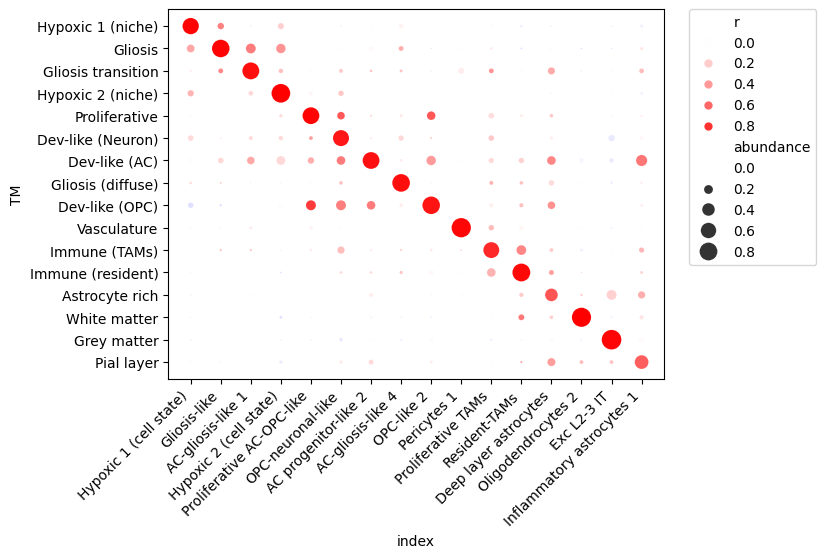

In [ ]:
sns.scatterplot(data=plot_df, x = 'index', y = 'TM', 
                size = 'abundance', hue = 'r', 
                palette="bwr", hue_norm=(-1, 1),
                sizes=(0, 200)
)
# rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# move legend to the right
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)
plt.show()

In [ ]:
plot_df.to_csv(os.path.join(output_dir, 'EDFig3a.1'))

# TM occurrence

In [ ]:
# Get total abundance of each niche
TM_occurrence = []
for tumour in tumours:
    niche_totals = niche_output[tumour].sum()
    niche_totals = niche_totals.divide(niche_totals.sum())
    niche_totals.name = 'abundance'
    niche_totals = pd.DataFrame(niche_totals)
    niche_totals['tumour'] = tumour
    TM_occurrence.append(niche_totals)
TM_occurrence = pd.concat(TM_occurrence).reset_index()

TM_occurrence["index"] = pd.Categorical(
    TM_occurrence["index"],
    categories=TM_order_from_paper,
    ordered=True
)


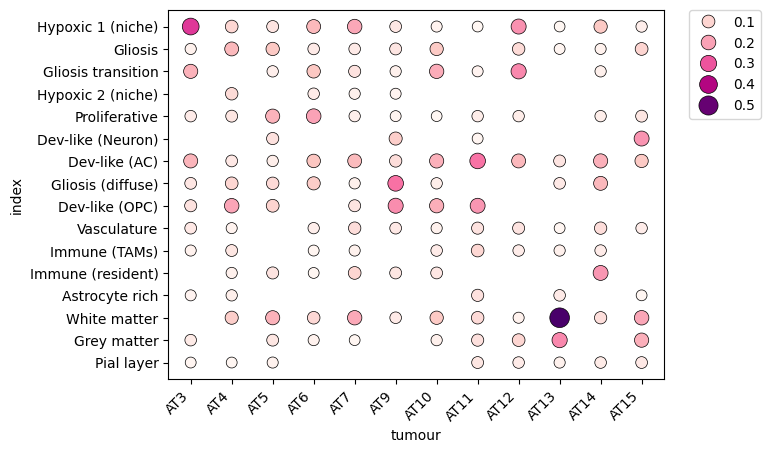

In [ ]:
sns.scatterplot(data=TM_occurrence, x = 'tumour', y = 'index', 
                size = 'abundance', hue = 'abundance', palette = 'RdPu',
                sizes = (60, 200), edgecolor="black", linewidth=0.5,
)
# rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# move legend to the right
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)
plt.show()

In [ ]:
TM_occurrence.to_csv(os.path.join(output_dir, 'EDFig3a.2'))

# Histopath

In [ ]:
feature_threshold = 0.9

In [ ]:
# get input df
global_summary = []

TM_list = []
histopaths = []
for tumour in histopath_output.keys():
    niche_df = niche_output[tumour]
    histopath_df = histopath_output[tumour]

    niche_df = niche_df[niche_df.index.isin(histopath_df.index)]

    TM_list.append(niche_df.columns.tolist())
    histopaths.append(histopath_df.columns.tolist())

    global_summary.append(pd.concat([niche_df, histopath_df], axis=1))
global_summary = pd.concat(global_summary)

TM_list = sorted(list(set([i for l in TM_list for i in l])))
histopaths = sorted(list(set([i for l in histopaths for i in l])))

In [ ]:
comparison_summary = []
for annotation in histopaths:

    # overlap
    composition = global_summary[global_summary[annotation]>=feature_threshold]
    composition = composition[TM_list].sum(skipna=True)
    composition = composition.divide(composition.sum())
    composition.name = 'proportion'
    composition = pd.DataFrame(composition).reset_index()
    composition['histopath_feature'] = annotation

    # correlation
    correlation = []
    for niche in TM_list:
        comp_df = global_histopath_summary[[niche, annotation]].dropna()
        comp_df['feature_range'] = np.where(comp_df[annotation]>feature_threshold, 1, 0)

        if len(comp_df)>1:            
            corr, p_value = pointbiserialr(comp_df[annotation], comp_df[niche])
            correlation.append(pd.DataFrame({
                'index':niche,
                'histopath_feature':annotation,
                'r':corr,
                'p':p_value,
            }, index=[0]))
    correlation = pd.concat(correlation)

    comparison_summary.append(pd.concat([
        composition.set_index(['index', 'histopath_feature']),
        correlation.set_index(['index', 'histopath_feature'])
    ], axis=1))
comparison_summary = pd.concat(comparison_summary).reset_index()

In [ ]:
comparison_summary["index"] = pd.Categorical(
    comparison_summary["index"],
    categories=TM_order_from_paper,
    ordered=True
)

histopath_paper_order = [
 'Necrosis',
 'Pseudopalisading cells around necrosis',
 'Perinecrotic zone',
 'Cellular tumor',
 'Hyperplastic blood vessels',
 'Microvascular proliferation',
 'Leading edge (white matter)',
 'Infiltrating tumor (white matter)',
 'Leading edge (grey matter)',
 'Infiltrating tumor (grey matter)',
]

comparison_summary["histopath_feature"] = pd.Categorical(
    comparison_summary["histopath_feature"],
    categories=histopath_paper_order,
    ordered=True
)

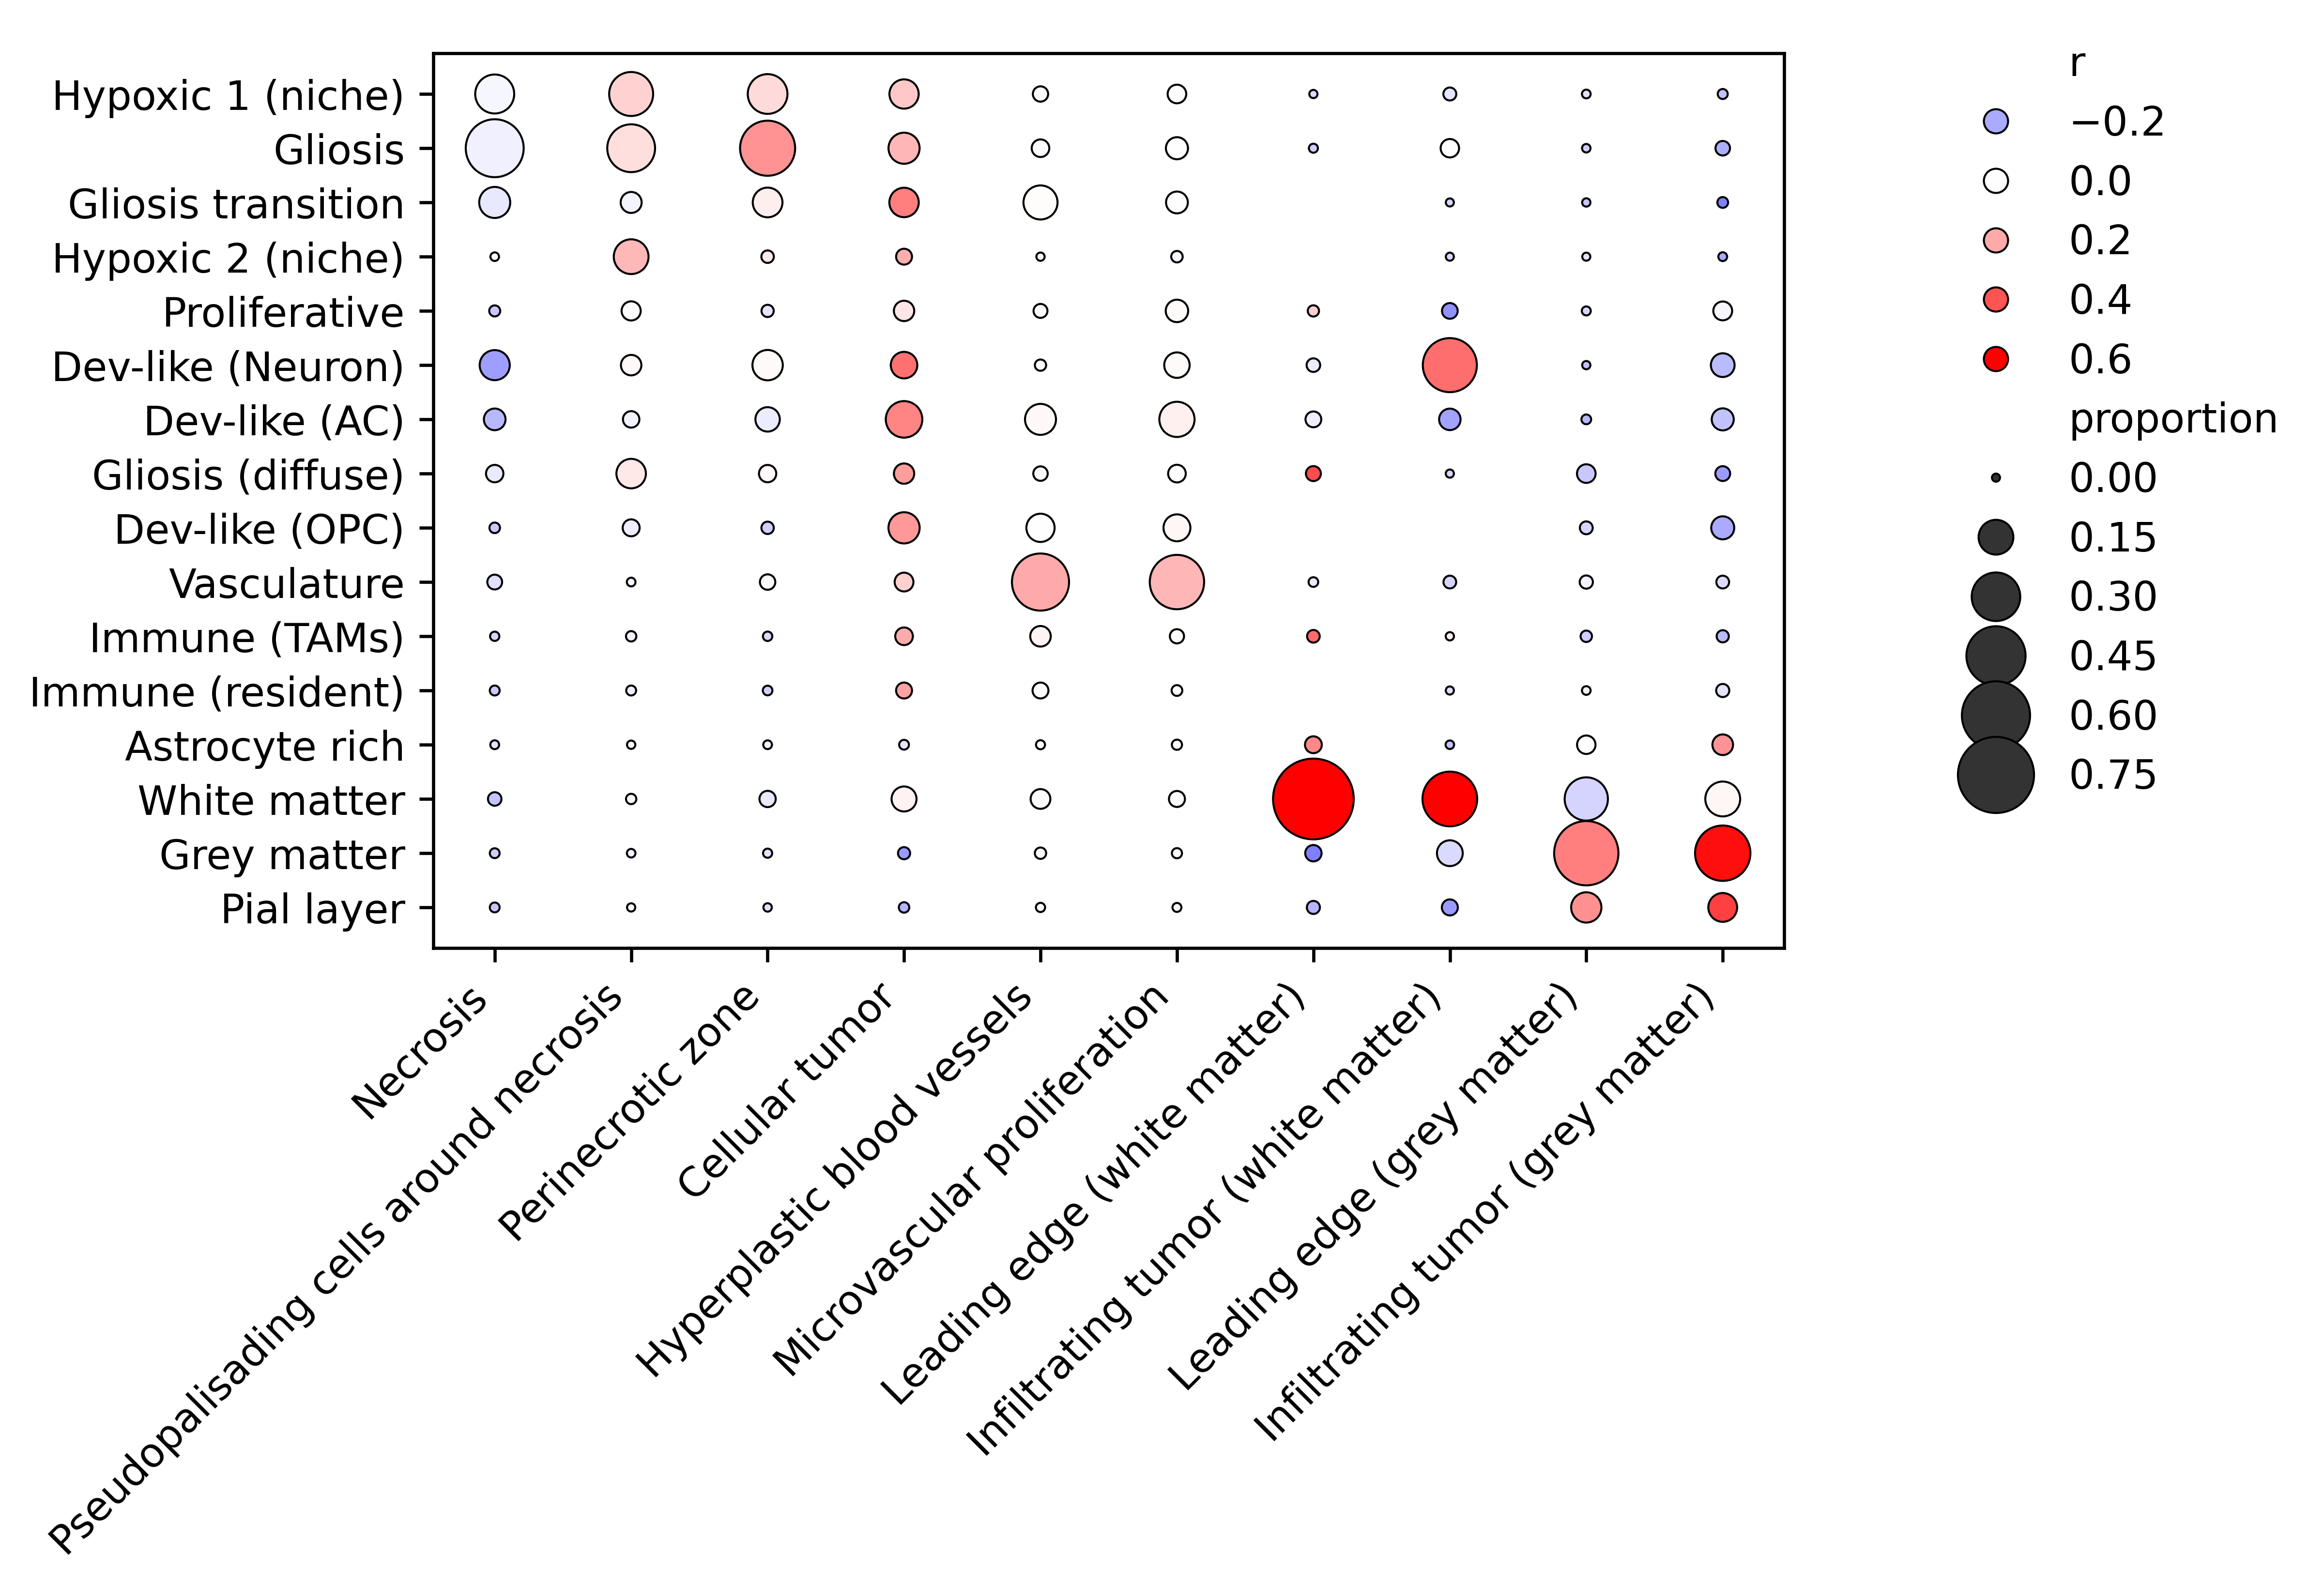

In [ ]:
f, ax = plt.subplots(figsize=(6, 4), sharey=True, dpi=600)
sns.scatterplot(data=comparison_summary, x = 'histopath_feature', y = 'index',
                size = 'proportion', hue = 'r',
                sizes=(4, 400),
                hue_norm=(-0.6, 0.6),
                palette='bwr',
                edgecolor="black", linewidth=0.5
               )
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.1, 1.05), frameon=False)
plt.xlabel('')
plt.ylabel('')
plt.show()

In [ ]:
comparison_summary.to_csv(os.path.join(output_dir, 'EDFig3a.3'))

## Perinecrotic

In [ ]:
feature_threshold = 0.9

In [ ]:
# get input df
global_peri_summary = []

for tumour in histopath_output.keys():
    ct_df = abundance_output[tumour]
    histopath_df = histopath_output[tumour]

    ct_df = ct_df[ct_df.index.isin(histopath_df.index)]

    global_peri_summary.append(pd.concat([ct_df, histopath_df], axis=1))
global_peri_summary = pd.concat(global_peri_summary)

histopaths = ['Cellular tumor',
 'Hyperplastic blood vessels',
 'Infiltrating tumor (grey matter)',
 'Infiltrating tumor (white matter)',
 'Leading edge (grey matter)',
 'Leading edge (white matter)',
 'Microvascular proliferation',
 'Necrosis',
 'Perinecrotic zone',
 'Pseudopalisading cells around necrosis']

ct_list = [
'Hypoxic 1 (cell state)',
'Gliosis-like',
'AC-gliosis-like 1',
'AC progenitor-like 1',
'AC progenitor-like 2',
'OPC-NPC-like 1',
]

In [ ]:
peri_comparison_summary = []
for annotation in histopaths:

    # overlap
    composition = global_peri_summary[global_peri_summary[annotation]>=feature_threshold]
    composition = composition[ct_list].sum(skipna=True)
    composition = composition.divide(composition.sum())
    composition.name = 'proportion'
    composition = pd.DataFrame(composition).reset_index()
    composition['histopath_feature'] = annotation

    # correlation
    correlation = []
    for ct in ct_list:
        comp_df = global_peri_summary[[ct, annotation]].dropna()
        comp_df['feature_range'] = np.where(comp_df[annotation]>feature_threshold, 1, 0)

        if len(comp_df)>1:            
            corr, p_value = pointbiserialr(comp_df[annotation], comp_df[ct])
            correlation.append(pd.DataFrame({
                'index':ct,
                'histopath_feature':annotation,
                'r':corr,
                'p':p_value,
            }, index=[0]))
    correlation = pd.concat(correlation)

    peri_comparison_summary.append(pd.concat([
        composition.set_index(['index', 'histopath_feature']),
        correlation.set_index(['index', 'histopath_feature'])
    ], axis=1))
peri_comparison_summary = pd.concat(peri_comparison_summary).reset_index()

In [ ]:
peri_comparison_summary["index"] = pd.Categorical(
    peri_comparison_summary["index"],
    categories=ct_list,
    ordered=True
)

histopath_paper_order = [
 'Necrosis',
 'Pseudopalisading cells around necrosis',
 'Perinecrotic zone',
 'Cellular tumor'
]

peri_comparison_summary["histopath_feature"] = pd.Categorical(
    peri_comparison_summary["histopath_feature"],
    categories=histopath_paper_order,
    ordered=True
)

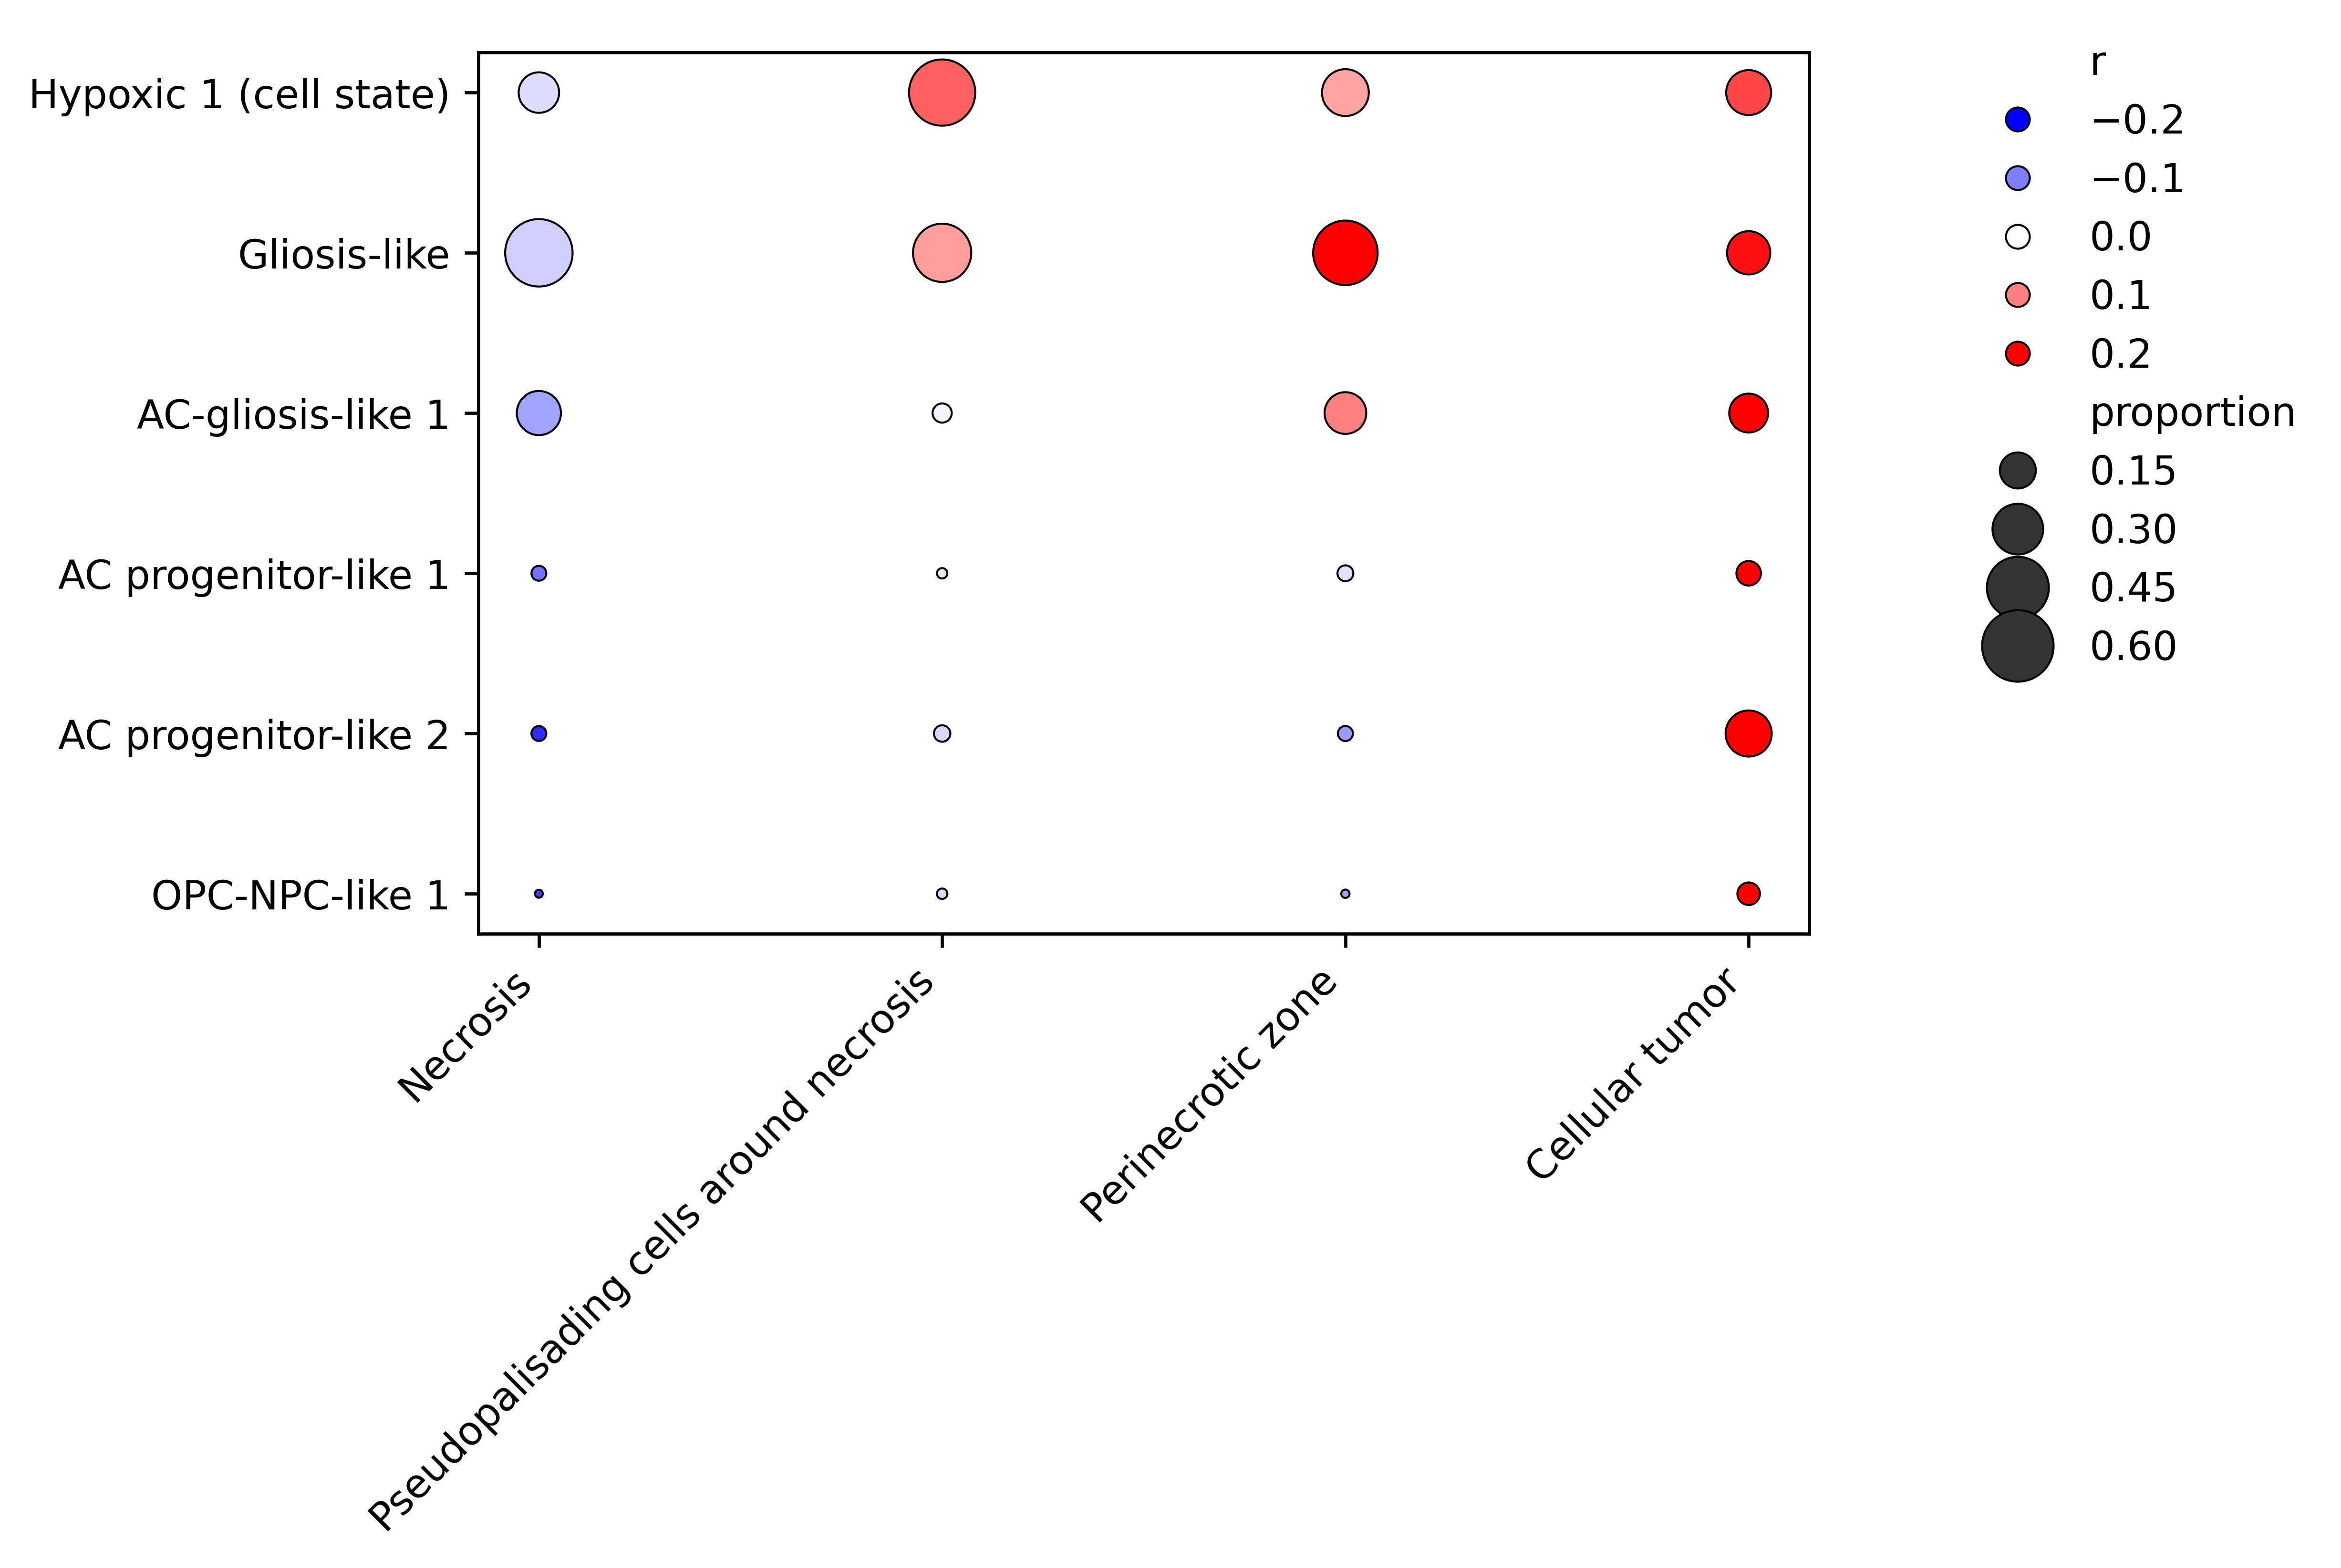

In [ ]:
f, ax = plt.subplots(figsize=(6, 4), sharey=True, dpi=600)
sns.scatterplot(data=peri_comparison_summary, x = 'histopath_feature', y = 'index',
                size = 'proportion', hue = 'r',
                sizes=(4, 400),
                hue_norm=(-0.2, 0.2),
                palette='bwr',
                edgecolor="black", linewidth=0.5
               )
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.1, 1.05), frameon=False)
plt.xlabel('')
plt.ylabel('')
plt.show()

In [ ]:
peri_comparison_summary.to_csv(os.path.join(output_dir, 'Fig3a.3'))